This notebook select a track along the 200m isobath using the bathymetry from GLORYS12
1. Track selection 
* It select the 200m isobath and transform into a track with 200 points and compute the culumative distance
* Plot the track 

2. MIOST Hovmoller
* Interpolation of MIOST data along the track
* Application of a high pass filter (cutoff frequency of 30 days) 
* Hovmoller plotting 

3.Download of SST data from CMEMS  

4.SST Hovmoller 
* Interpolation of SST data along the track
* Application of a high pass filter (cutoff frequency of 30 days) 
* Hovmoller plotting 

5. Compute correlation between SST and SSHa along the track

6. Extraction of swot data along the track, this function select the comun points between the track defined and SWOT Swath

7. Map of the selected points 

8. SWOT Hovmoller

9. SWOT filter and hovmoller

10. Spectra computation

Import libraries

In [17]:
import xarray as xr
import numpy as np
from scipy.spatial import KDTree
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from netCDF4 import Dataset
import glob
from scipy.signal import detrend, butter, filtfilt
import scipy.stats as stats
import matplotlib.colors as colors
from scipy.ndimage import uniform_filter1d


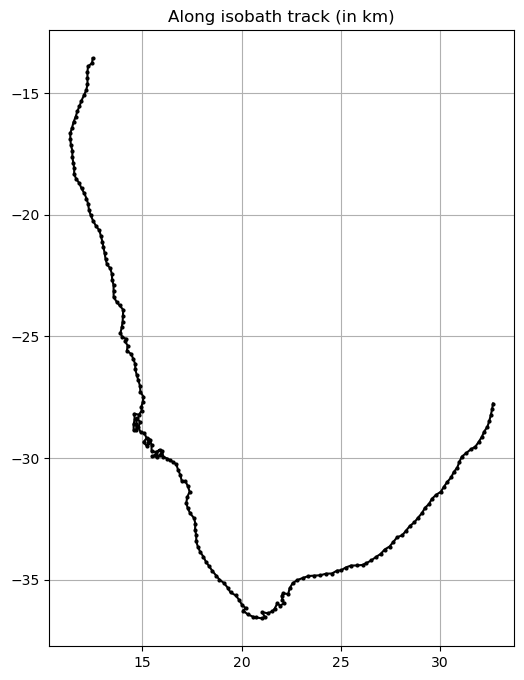

 'Track_isobath.nc' saved with cumulative distance in km.


In [16]:
#### 1. Selection of the track following an isobath
def haversine_dist(lat1, lon1, lat2, lon2):

    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

###################################################################################################################
# Import data and select the region
###################################################################################################################
file_path = '/Users/ABC/Desktop/post_docmercator/GLO-MFC_001_024_mask_bathy.nc'
with Dataset(file_path, 'r') as nc:
    lon_full = nc.variables['longitude'][:]
    lat_full = nc.variables['latitude'][:]
    bathy_full = nc.variables['deptho'][:]

lon_idx = np.where((lon_full >= 0) & (lon_full <= 35))[0]
lat_idx = np.where((lat_full >= -38) & (lat_full <= 0))[0]

longB = lon_full[lon_idx]
latB = lat_full[lat_idx]
Bathy3 = bathy_full[np.ix_(lat_idx, lon_idx)]

###################################################################################################################
# Contour extraction & Cleaning
###################################################################################################################
fig = plt.figure()
cs = plt.contour(longB, latB, Bathy3, levels=[200])
plt.close(fig)

all_paths = cs.get_paths()
coords_brutes = np.vstack([path.vertices for path in all_paths])

# if Distance > 2 degrees 
dist_points = np.sqrt(np.sum(np.diff(coords_brutes, axis=0)**2, axis=1))
indices_sauts = np.where(dist_points > 2.0)[0]
sous_segments = np.split(coords_brutes, indices_sauts + 1)
coords_fusionnees = max(sous_segments, key=len)

Xcrop, Ycrop = coords_fusionnees[:, 0], coords_fusionnees[:, 1]

###################################################################################################################
#Interpolation
###################################################################################################################
# Distance in km
dist_segments_km = [haversine_dist(Ycrop[i], Xcrop[i], Ycrop[i+1], Xcrop[i+1]) for i in range(len(Xcrop)-1)]
cumdist_km = np.concatenate(([0], np.cumsum(dist_segments_km)))

# Interpolation
d_interp_km = np.linspace(0, cumdist_km[-1], 200)
f_lon = interp1d(cumdist_km, Xcrop, kind='linear')
f_lat = interp1d(cumdist_km, Ycrop, kind='linear')
lon_final, lat_final = f_lon(d_interp_km), f_lat(d_interp_km)


lon_final = lon_final[::-1]
lat_final = lat_final[::-1]

dist_segments_km = [haversine_dist(lat_final[i], lon_final[i], lat_final[i+1], lon_final[i+1]) 
                    for i in range(len(lon_final)-1)]

d_interp_km = np.concatenate(([0], np.cumsum(dist_segments_km)))
###################################################################################################################
# NetCDF Export 
###################################################################################################################
with Dataset('Track_isobath.nc', 'w', format='NETCDF4') as nc_out:
    nc_out.createDimension('npoints', 200)
    
    v_lon = nc_out.createVariable('lon_final', 'f4', ('npoints',))
    v_lat = nc_out.createVariable('lat_final', 'f4', ('npoints',))
    v_dist = nc_out.createVariable('cumulative_dist_km', 'f4', ('npoints',))
    
    v_lon[:] = lon_final
    v_lat[:] = lat_final
    v_dist[:] = d_interp_km
    
    v_dist.units = 'km'
    v_dist.description = 'Distance cumulative le long de l isobathe en km'

###################################################################################################################
# Plot
###################################################################################################################
plt.figure(figsize=(6, 8))
plt.plot(lon_final, lat_final, 'k-o', markersize=2, label='Track')
plt.title("Along isobath track (in km)")
plt.grid(True)
plt.show()

print(" 'Track_isobath.nc' saved with cumulative distance in km.")

/var/folders/7w/pf1hh9m156bbf5hz9g84bxc40000gq/T/ipykernel_24824/3949642442.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = plt.cm.get_cmap('RdBu_r', n_levels)


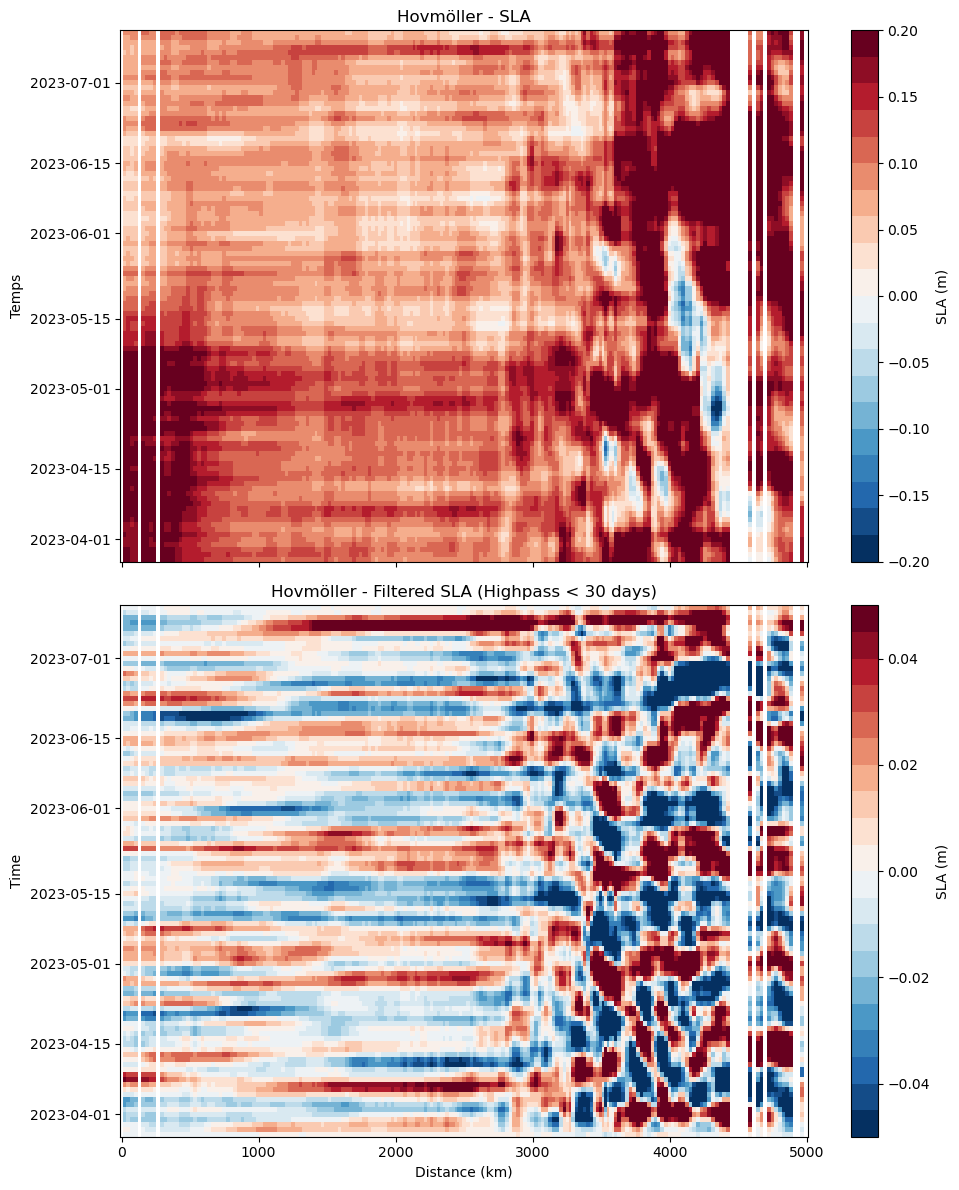

In [38]:
#### 2. MIOST Hovmoller 
###################################################################################################################
#track data
###################################################################################################################

ds_track = xr.open_dataset('/Users/ABC/Desktop/munich/Track_isobath.nc')
lons = ds_track.lon_final.values
lats = ds_track.lat_final.values
dist = ds_track.cumulative_dist_km.values
###################################################################################################################
# MIOST DATA
###################################################################################################################

file_pattern = '/Users/ABC/Desktop/SWOT/calval/dt_global_allsat_phy_l4_*.nc'
files = sorted(glob.glob(file_pattern))

if not files:
    raise FileNotFoundError(f"Aucun fichier trouvé avec le motif : {file_pattern}")

ds = xr.open_mfdataset(files, concat_dim='time', combine='nested')
###################################################################################################################
# ALONG track
###################################################################################################################

track_coords = xr.Dataset(
    {'lon': (('npoints'), lons), 'lat': (('npoints'), lats)},
    coords={'npoints': np.arange(len(lons))}
)

# Extraction et interpolation of SLA

hovmoller_data = ds.sla.interp(longitude=track_coords.lon, latitude=track_coords.lat, method='linear').compute()
hovmoller_data = hovmoller_data.interpolate_na(dim='time', method='linear', limit=5)
###################################################################################################################
# Filter
###################################################################################################################

fc = 1/30 # 1/30 days cuttoff frequency
b, a = butter(4, fc, btype='high', analog=False, fs=1.0)

# Application of the butterworth filter
sla_filtered = xr.apply_ufunc(
    lambda x: filtfilt(b, a, x, axis=0),
    hovmoller_data,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask="forbidden"
)
###################################################################################################################
# Hovmöllers
###################################################################################################################

fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)
n_levels=20
cmap1 = plt.cm.get_cmap('RdBu_r', n_levels)
# Plot Brut
im1 = axes[0].pcolormesh(dist, hovmoller_data.time, hovmoller_data.values,
                         cmap=cmap1, shading='auto', vmin=-0.2, vmax=0.2)
axes[0].set_title('Hovmöller - SLA')
axes[0].set_ylabel('Temps')
plt.colorbar(im1, ax=axes[0], label='SLA (m)')

#Filtered SLA
im2 = axes[1].pcolormesh(dist, sla_filtered.time, sla_filtered.values.T,
                         cmap=cmap1, shading='auto', vmin=-0.05, vmax=0.05)
axes[1].set_title('Hovmöller - Filtered SLA (Highpass < 30 days)')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Time')
plt.colorbar(im2, ax=axes[1], label='SLA (m)')

plt.tight_layout()
plt.show()



In [36]:
## 3. Download of SST data from CMEMS 
import copernicusmarine

copernicusmarine.subset(
  dataset_id="METOFFICE-GLO-SST-L4-REP-OBS-SST",
  variables=["analysed_sst"],
  minimum_longitude=0,
  maximum_longitude=35,
  minimum_latitude=-38,
  maximum_latitude=0,
  start_datetime="2023-03-28T00:00:00",
  end_datetime="2023-07-11T00:00:00",
)


INFO - 2026-06-12T13:23:22Z - Selected dataset version: "202003"
INFO - 2026-06-12T13:23:22Z - Selected dataset part: "default"
INFO - 2026-06-12T13:23:24Z - Starting download. Please wait...


  0%|          | 0/212 [00:00<?, ?it/s]

INFO - 2026-06-12T13:23:28Z - Successfully downloaded to METOFFICE-GLO-SST-L4-REP-OBS-SST_analysed_sst_0.03E-34.97E_37.97S-0.03S_2023-03-28-2023-07-11.nc


ResponseSubset(file_path=PosixPath('METOFFICE-GLO-SST-L4-REP-OBS-SST_analysed_sst_0.03E-34.97E_37.97S-0.03S_2023-03-28-2023-07-11.nc'), output_directory=PosixPath('.'), filename='METOFFICE-GLO-SST-L4-REP-OBS-SST_analysed_sst_0.03E-34.97E_37.97S-0.03S_2023-03-28-2023-07-11.nc', file_size=107.63132061068703, data_transfer_size=848.4660763358779, variables=['analysed_sst'], coordinates_extent=[GeographicalExtent(minimum=0.02500000037252903, maximum=34.974998474121094, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=-37.974998474121094, maximum=-0.02500000037252903, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2023-03-28T00:00:00+00:00', maximum='2023-07-11T00:00:00+00:00', unit='iso8601', coordinate_id='time')], status='000', message='The request was successful.', file_status='DOWNLOADED')

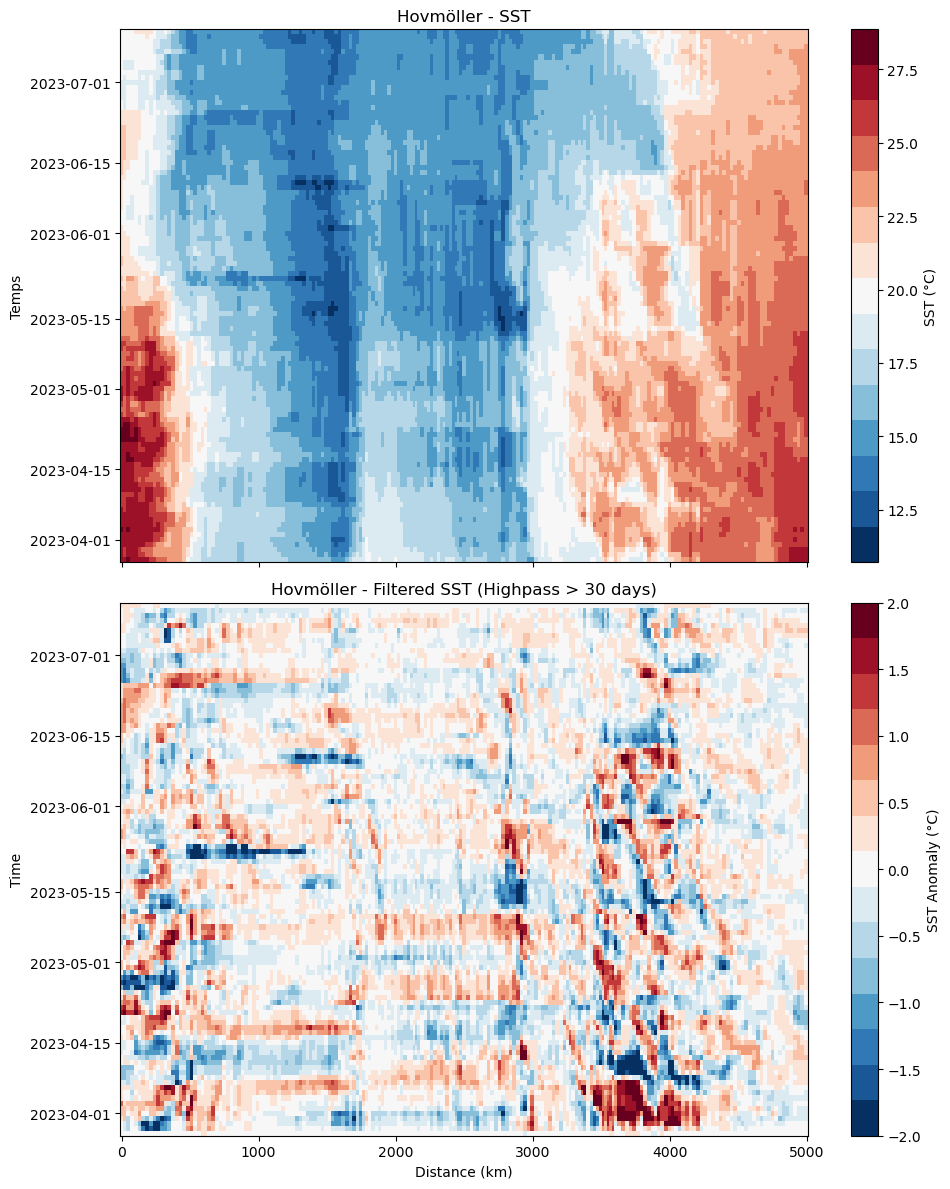

In [40]:
#### 4. SST Hovmoller 
###################################################################################################################
# Track data
###################################################################################################################
ds_track = xr.open_dataset('/Users/ABC/Desktop/munich/Track_isobath.nc')
lons = ds_track.lon_final.values
lats = ds_track.lat_final.values
dist = ds_track.cumulative_dist_km.values

###################################################################################################################
# SST DATA (Fichier unique)
###################################################################################################################
file_path = '/Users/ABC/Desktop/munich/METOFFICE-GLO-SST-L4-REP-OBS-SST_analysed_sst_0.03E-34.97E_37.97S-0.03S_2023-03-28-2023-07-11.nc'
ds = xr.open_dataset(file_path)

# Note : Vérifiez le nom de la variable SST dans votre fichier. 
# Si c'est 'analysed_sst' ou 'sst', remplacez ci-dessous.
# J'utilise 'analysed_sst' basé sur votre nom de fichier.
var_name = 'analysed_sst' 

###################################################################################################################
#Along track extraction
###################################################################################################################
# On crée le Dataset avec les noms qui correspondent à votre fichier SST
track_coords = xr.Dataset(
    {'longitude': (('npoints'), lons), 'latitude': (('npoints'), lats)},
    coords={'npoints': np.arange(len(lons))}
)

hovmoller_data_sst = ds[var_name].interp(
    longitude=track_coords.longitude, 
    latitude=track_coords.latitude, 
    method='linear'
).compute()

# Interpolation des valeurs manquantes le long de l'axe temporel
hovmoller_data_sst = hovmoller_data_sst.interpolate_na(dim='time', method='linear', limit=5)
###################################################################################################################
#Filter (Highpass 30 days)
###################################################################################################################
fc = 1/30 
b, a = butter(4, fc, btype='high', analog=False, fs=1.0)

sst_filtered = xr.apply_ufunc(
    lambda x: filtfilt(b, a, x, axis=0),
    hovmoller_data_sst,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask="forbidden"
)

###################################################################################################################
# Hovmöllers
###################################################################################################################
n_levels = 15
cmap1 = plt.get_cmap('RdBu_r', n_levels)

fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# Plot Brut (.values.T pour aligner temps/distance)
im1 = axes[0].pcolormesh(dist, hovmoller_data_sst.time, hovmoller_data_sst.values-273.15,
                         cmap=cmap1, shading='nearest')
axes[0].set_title('Hovmöller - SST')
axes[0].set_ylabel('Temps')
plt.colorbar(im1, ax=axes[0], label='SST (°C)')

# Plot Filtré
im2 = axes[1].pcolormesh(dist, sst_filtered.time, sst_filtered.values.T,
                         cmap=cmap1, shading='nearest',vmin=-2, vmax=2)
axes[1].set_title('Hovmöller - Filtered SST (Highpass > 30 days)')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Time')
plt.colorbar(im2, ax=axes[1], label='SST Anomaly (°C)')

plt.tight_layout()
plt.show()

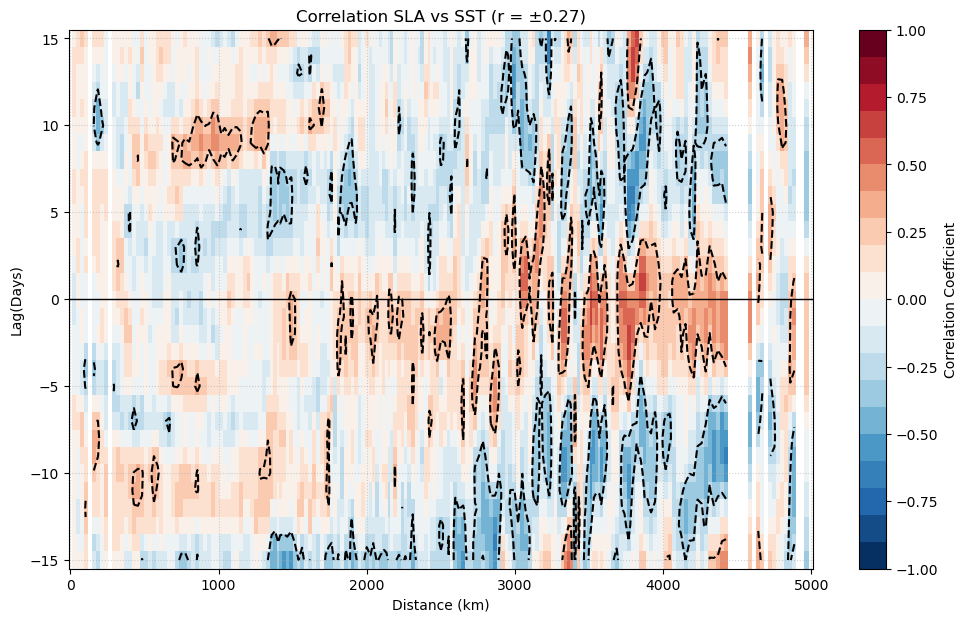

In [36]:
## 5. Correlation between SSTa and SSha 
common_time = sla_filtered.time.sel(time=sst_filtered.time.values).values
sla_aligned = sla_filtered.sel(time=common_time)
sst_aligned = sst_filtered.sel(time=common_time)

###################################################################################################################
#Correlation with Lag & Significance
###################################################################################################################
lags = np.arange(-15, 16)
corr_list = []

for lag in lags:
    sst_shifted = sst_aligned.shift(time=lag)
    corr_list.append(xr.corr(sla_aligned, sst_shifted, dim='time'))

corr_matrix = xr.concat(corr_list, dim='lag').assign_coords(lag=lags).values.T # Shape: (lag, npoints)

#Significance (t-student)
n = len(common_time)
# Correction pour autocorrélation (degrés de liberté effectifs simplifiés)
a1_sla = xr.corr(sla_aligned, sla_aligned.shift(time=1), dim='time').mean()
n_eff = n * (1 - a1_sla) / (1 + a1_sla)
t_crit = stats.t.ppf(0.85, df=n_eff-2)
r_crit = np.sqrt(t_crit**2 / (n_eff - 2 + t_crit**2))

###################################################################################################################
# PLOT
###################################################################################################################
plt.figure(figsize=(12, 7))
cmap = plt.get_cmap('RdBu_r', 20)

im = plt.pcolormesh(dist, lags, corr_matrix.T, cmap=cmap, vmin=-1, vmax=1, shading='nearest')

# Contour de significativité
plt.contour(dist, lags, corr_matrix.T, levels=[-r_crit, r_crit], 
            colors='black', linewidths=1.5, linestyles='--')

plt.colorbar(im, label='Correlation Coefficient')
plt.xlabel('Distance (km)')
plt.ylabel('Lag(Days)')
plt.title(f'Correlation SLA vs SST (r = ±{r_crit:.2f})')
plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Extraction of swot data along the track, this function select the comun points between the track defined and SWOT Swath

In [8]:
## 6. Extraction of SWOT ssha data along the track 

def extract_swot_on_track_kdtree(ds, track_lon, track_lat, threshold_km=20):

    # original Dimensions : (cycle, num_lines, num_pixels)

    lons_flat = ds.longitude[0, :, :].values.ravel()
    lats_flat = ds.latitude[0, :, :].values.ravel()
    
    points = np.column_stack((lats_flat, lons_flat))
    tree = KDTree(points)
    
    n_cycles = ds.ssha_unfiltered.shape[0]
    n_points = len(track_lon)
    result = np.full((n_cycles, n_points), np.nan)
 ######################################################################################################################################################
      # closest neibours
######################################################################################################################################################

    dists, indices = tree.query(np.column_stack((track_lat, track_lon)), k=1)
    
    # degrees -> km ( 1 deg ~ 111 km)
    dists_km = dists * 111.0 
    
######################################################################################################################################################
#extraction
######################################################################################################################################################

    n_lines = ds.num_lines.size
    n_pixels = ds.num_pixels.size
    
    for i in range(n_points):
        if dists_km[i] < threshold_km:
            # Conversion de l'index du KDTree (0 à N*M) vers (line, pixel)
            l, p = divmod(indices[i], n_pixels)
            # Extraction de la série temporelle entière pour ce pixel (tous les cycles)
            result[:, i] = ds.ssha_unfiltered[:, l, p].values
            
######################################################################################################################################################
 #dates
######################################################################################################################################################

    dates = ds.time.mean(dim=['num_lines', 'num_pixels']).values
    
    return xr.DataArray(
        result,
        coords={
            'date': ('time_idx', dates),
            'npoints': np.arange(n_points)
        },
        dims=('time_idx', 'npoints')
    )


swot_p1 = extract_swot_on_track_kdtree(ds_p1, ds_track.lon_final.values, ds_track.lat_final.values)
swot_p16 = extract_swot_on_track_kdtree(ds_p16, ds_track.lon_final.values, ds_track.lat_final.values)

# Fusion
hovmoller_swot = xr.concat([swot_p1, swot_p16], dim='time_idx')
hovmoller_swot = hovmoller_swot.assign_coords(date=hovmoller_swot.date.dt.floor('D'))
hovmoller_swot = hovmoller_swot.groupby('date').mean(dim='time_idx', skipna=True).sortby('date')

print("SIZE :", hovmoller_swot.shape)


######################################################################################################################################################
# save into netcdf
######################################################################################################################################################

output_file = '/Users/ABC/Desktop/munich/swot_hovmoller_result.nc'
hovmoller_swot.to_netcdf(output_file)
print(f"success: {output_file}")




Succès ! Dimensions finales : (102, 200)


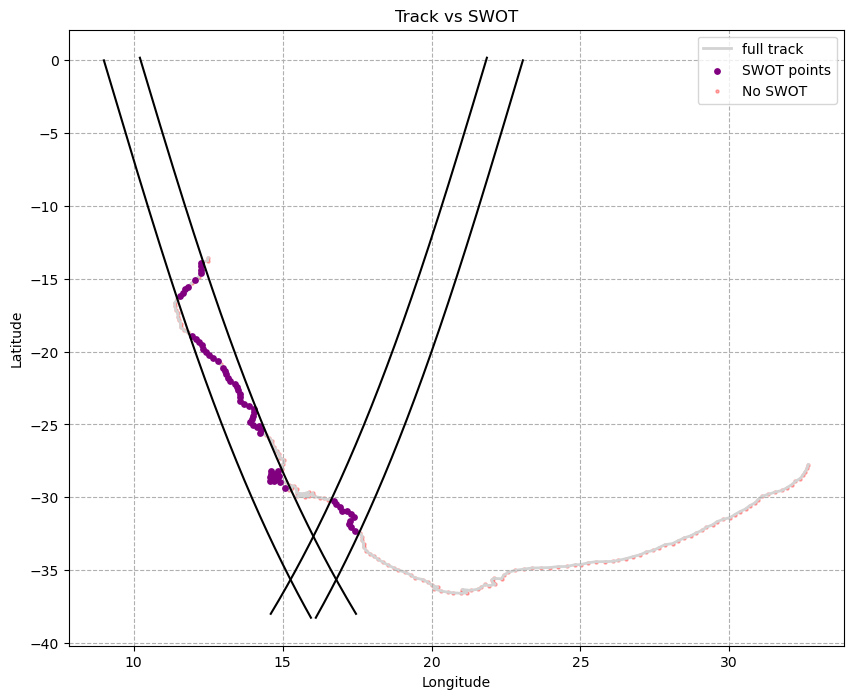

In [27]:
## 7.Plot map of selected points 

def plot_final_map(ds_track, hovmoller_swot):
    plt.figure(figsize=(10, 8))
    
    # 1. Tracer le track complet en gris clair
    plt.plot(ds_track.lon_final, ds_track.lat_final, 
             color='lightgray', label='full track', lw=2, zorder=1)
    
######################################################################################################################################################
    valid_mask = hovmoller_swot.notnull().any(dim='date').values
######################################################################################################################################################  
# SWOT POINTS ALONG THE TRACK
########################################################################################################################
    plt.scatter(ds_track.lon_final[valid_mask], 
                ds_track.lat_final[valid_mask], 
                c='purple', s=15, label='SWOT points', zorder=2)
    
    # Track without SWOT SWATH crossing
    invalid_mask = ~valid_mask
    plt.scatter(ds_track.lon_final[invalid_mask], 
                ds_track.lat_final[invalid_mask], 
                color='red', s=5, label='No SWOT', alpha=0.3, zorder=0)
    plt.plot(ds_p1.longitude[0,:,0],ds_p1.latitude[0,:,0],color='black')
    plt.plot(ds_p1.longitude[0,:,-1],ds_p1.latitude[0,:,-1],color='black')
    plt.plot(ds_p16.longitude[0,:,0],ds_p16.latitude[0,:,0],color='black')
    plt.plot(ds_p16.longitude[0,:,-1],ds_p16.latitude[0,:,-1],color='black')

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Track vs SWOT')
    plt.legend()
    plt.grid(True, linestyle='--')
    plt.show()


plot_final_map(ds_track, hovmoller_swot)

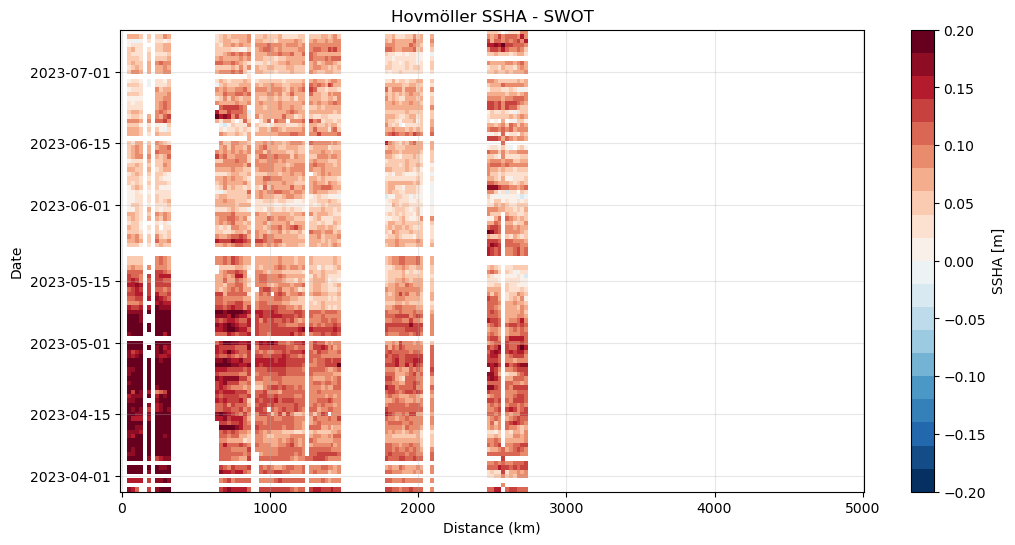

In [25]:
## 8.Plot SWOT hovmoller 
plt.figure(figsize=(12, 6))

##############################
#SWOT hovmoller
##############################
n_levels=20
cmap1 = plt.get_cmap('RdBu_r', n_levels)

im = plt.pcolormesh(
    dist, 
    hovmoller_swot.date, 
    hovmoller_swot.values, 
    cmap=cmap1, 
    shading='auto',vmin=-0.2,vmax=0.2,
)

plt.colorbar(im, label='SSHA [m]')
plt.title('Hovmöller SSHA - SWOT')
plt.xlabel('Distance (km)')
plt.ylabel('Date')
plt.grid(True, alpha=0.3)
plt.show()

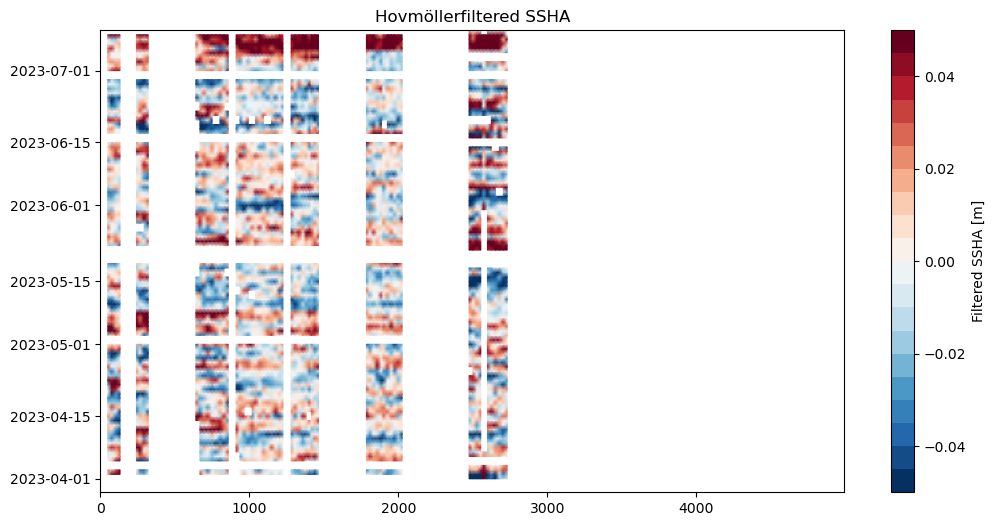

In [26]:
## 9.SWOT filter and hovmoller

hovmoller_clean = hovmoller_swot.interpolate_na(dim='date', method='linear', limit=5)

# Edge NaNs replaced by 0
hovmoller_clean = hovmoller_clean.fillna(0)

# Filter application
# fc = 1/30 (cut off frequency : 30 jours)
# fs = 1.0   (Sampling frequency)
fc = 1/30 
b, a = butter(4, fc, btype='high', analog=False, fs=1.0)

# Filter application
sla_filtered = xr.apply_ufunc(
    lambda x: filtfilt(b, a, x, axis=0),
    hovmoller_clean,
    input_core_dims=[['date']],
    output_core_dims=[['date']],
    vectorize=True,
    dask="forbidden"
)

# Puts the NaNs back 
sla_filtered = sla_filtered.where(hovmoller_swot.notnull())
n_levels=20
cmap1 = plt.get_cmap('RdBu_r', n_levels)

# Plot
plt.figure(figsize=(12, 6))
im = plt.pcolormesh(
    dist, 
    sla_filtered.date, 
    sla_filtered.values.T, 
    cmap=cmap1, 
    vmin=-0.05, vmax=0.05, 
    shading='gouraud'
)
plt.colorbar(im, label='Filtered SSHA [m]')
plt.title('Hovmöllerfiltered SSHA')
plt.show()

In [ ]:
## 10. SPECTRA computation
##############################
## SPECTRA COMPUTATION
def yo_spec(x, opt=1, nsmooth=5):
    """Calcul du spectre avec une taille fixe."""
    x = np.array(x)
    # Important : ne pas supprimer les NaN ici, on suppose qu'ils sont déjà gérés
    # On force une longueur fixe pour la FFT
    n = len(x)
    
    if opt >= 0: x = x - np.nanmean(x) # Utiliser nanmean au cas où
    if opt == 1: x = detrend(x, type='linear') # Gérer les NaN dans detrend si besoin
    
    fftx = np.fft.fft(x)
    ps_raw = np.abs(fftx[:n // 2]) ** 2
    ps_smooth = uniform_filter1d(ps_raw, size=nsmooth)
    freq = np.fft.fftfreq(n, d=1)[:n // 2]
    return ps_smooth, freq

# ##############################
##############################
#SPECTRA POINT by POINT
##############################

def compute_spectra_by_point(data_array, nsmooth=5):

    if not isinstance(data_array, xr.DataArray):
        data_array = xr.DataArray(data_array, dims=('date', 'npoints'))
    
    da_filled = data_array.interpolate_na(dim='date', method='linear', limit=5)
    
 
    da_filled = da_filled.fillna(0)
    
    arr = da_filled.values
    if arr.shape[0] < arr.shape[1]: 
        arr = arr.T
    
    n_time = arr.shape[0]
    n_points = arr.shape[1]
    
    freq = np.fft.fftfreq(n_time, d=1)[:n_time // 2]
    all_ps = np.full((n_points, len(freq)), np.nan)
    
    for i in range(n_points):
        signal = arr[:, i]
        # On vérifie encore une fois avant yo_spec
        if not np.any(np.isnan(signal)):
            P, f = yo_spec(signal, opt=1, nsmooth=nsmooth)
            if P is not None and len(P) == len(freq):
                all_ps[i, :] = P
            
    return all_ps, freq

variables = {
    'SSHa MIOST': hovmoller_data.values,
    'SSHa SWOT':  hovmoller_swot.values,
    'SST': hovmoller_data_sst.values
}

results = {}
for name, da in variables.items():
    print(f"Calcul du spectre pour : {name}...")
    results[name] = compute_spectra_by_point(da)


In [1]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
# Limits
min_period = 2    # 1/2 day
max_period = 50   # 1/50 day

# 2. Convertir en fréquences pour Matplotlib
freq_at_min = 1 / min_period # 0.5 cycle/days
freq_at_max = 1 / max_period # 0.02 cycle/days
for ax, (name, (ps_data, freq)) in zip(axes, results.items()):

    ps_masked = np.ma.masked_invalid(ps_data.T)
    
    vmin, vmax = np.nanpercentile(ps_data, [5, 95]) 
    
    pcm = ax.pcolormesh(
        dist[:ps_data.shape[0]], 
        freq, 
        ps_masked, 
        cmap='Spectral_r', 
        norm=colors.LogNorm(vmin=vmin, vmax=vmax), 
        shading='nearest'
    )
    ax.set_yticks([1/50, 1/30, 1/10, 1/5, 1/2])
    ax.set_yticklabels(['50', '30', '10', '5', '2'])
    
    
    ax.set_yscale('log')
    ax.set_yticks(freq_ticks)
    ax.set_yticklabels([str(p) for p in period_ticks])
    ax.set_ylim(freq.max(), freq.min())
    ax.set_ylim(freq_at_min, freq_at_max)

    ax.set_title(f'{name}')
    ax.set_xlabel('Distance [km]')
    if ax == axes[0]: ax.set_ylabel('Période [jours]')
    ax.grid(True, which="both", ls='--', lw=0.3)

plt.colorbar(pcm, ax=axes.ravel().tolist(), label='PSD (échelle normalisée)')
plt.suptitle('Spectres de puissance temporels', fontsize=14)
plt.show()

NameError: name 'plt' is not defined